In [31]:
import numpy as np
import pandas as pd

from src.simulation.synthetic_worlds.realistic_world import simulate_realistic_world
from src.simulation.train_lr_sim import train_logistic_regression
from src.simulation.train_mlp_sim import train_mlp_model, MLP_Realistic

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.metrics.evaluation import evaluate_model


SEED = 42
np.random.seed(SEED)


In [32]:
df = simulate_realistic_world(n_samples=10000, seed=SEED)
df.head()


,race,gender,age,ses,bmi,glucose_true,hba1c_true,glucose_measured,hba1c_measured,diabetes_true,diabetes_label
0,0,0,70.169189,0.381160,26.961787,94.888234,5.330995,84.337000,5.405459,0,0
1,2,1,49.973046,-0.780090,29.862743,89.706288,5.717056,91.350209,5.686007,1,1
2,1,1,40.183974,-0.318449,27.315790,93.981328,5.320664,96.036258,5.084547,1,1
3,0,1,51.476224,0.575729,27.047767,90.775143,5.748412,84.958016,5.839906,0,0
4,0,0,43.393592,1.191135,29.044337,78.164894,5.543759,65.419455,6.030847,0,0


In [33]:
features = ["glucose_measured", "hba1c_measured", "age", "bmi", "ses"]
target = "diabetes_label"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

# Keep sensitive attributes aligned
sens_test = df.loc[X_test.index][["gender", "race"]]


In [34]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


In [35]:
lr_results = train_logistic_regression(
    X_train_s, y_train,
    X_test_s, y_test
)

print("LR Accuracy:", lr_results["accuracy"])


LR Accuracy: 0.7


Epoch 1/40: train_loss=0.5748, train_acc=72.56, val_loss=0.5496, val_acc=73.40
Epoch 2/40: train_loss=0.5379, train_acc=74.30, val_loss=0.5480, val_acc=73.05
Epoch 3/40: train_loss=0.5354, train_acc=74.44, val_loss=0.5412, val_acc=73.25
Epoch 4/40: train_loss=0.5337, train_acc=74.62, val_loss=0.5402, val_acc=73.30
Epoch 5/40: train_loss=0.5325, train_acc=74.86, val_loss=0.5387, val_acc=73.75
Epoch 6/40: train_loss=0.5317, train_acc=74.54, val_loss=0.5387, val_acc=73.45
Epoch 7/40: train_loss=0.5309, train_acc=74.88, val_loss=0.5424, val_acc=73.35
Epoch 8/40: train_loss=0.5290, train_acc=74.67, val_loss=0.5387, val_acc=73.65
Epoch 9/40: train_loss=0.5273, train_acc=74.85, val_loss=0.5452, val_acc=73.10
Epoch 10/40: train_loss=0.5284, train_acc=74.76, val_loss=0.5394, val_acc=73.50
Epoch 11/40: train_loss=0.5288, train_acc=74.94, val_loss=0.5407, val_acc=73.40
Epoch 12/40: train_loss=0.5263, train_acc=75.05, val_loss=0.5423, val_acc=73.75
Epoch 13/40: train_loss=0.5258, train_acc=74.72, 

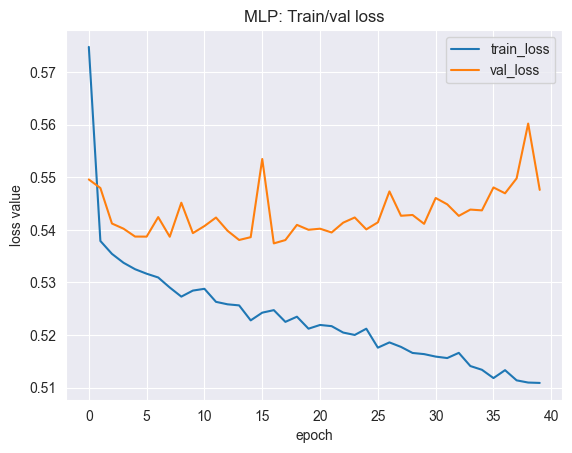

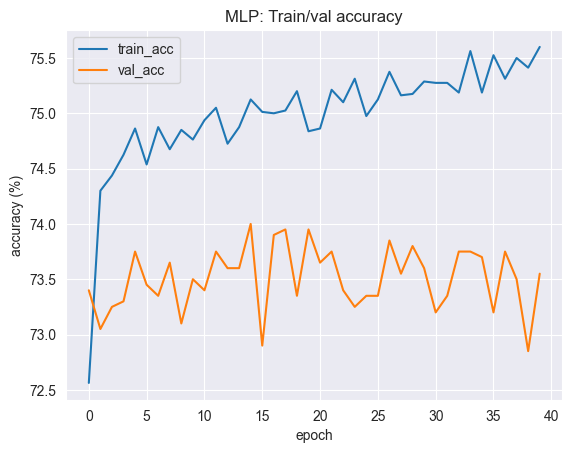

In [41]:
nn_results = train_mlp_model(
    X_train_s, y_train,
    X_test_s, y_test,
    input_dim=len(features),
    model_class=MLP_Realistic,
    n_epochs=40,
    lr=0.001
)

print("NN Accuracy:", nn_results["accuracy"])


In [37]:
# Reset indices to align masking with group labels
y_test = y_test.reset_index(drop=True)

y_pred_lr = pd.Series(lr_results["pred"]).reset_index(drop=True)
y_prob_lr = pd.Series(lr_results["probs"]).reset_index(drop=True)

y_pred_nn = pd.Series(nn_results["pred"]).reset_index(drop=True)
y_prob_nn = pd.Series(nn_results["probs"]).reset_index(drop=True)

sens_test = sens_test.reset_index(drop=True)


In [38]:
fair_lr = evaluate_model(y_test, y_pred_lr, y_prob_lr, sens_test)

print("\n=== LR Fairness Summary ===")
print(fair_lr)



=== LR Fairness Summary ===
{'accuracy': 0.7, 'precision': 0.7037037037037037, 'recall': 0.6751269035532995, 'gender_metrics': {np.int64(1): {'TPR': 0.6751592356687898, 'FNR': 0.32484076433121023, 'Precision': 0.6694736842105263, 'Calibration': 0.20338220557231815}, np.int64(0): {'TPR': 0.6750972762645915, 'FNR': 0.3249027237354085, 'Precision': 0.7382978723404255, 'Calibration': 0.20937990419966818}}, 'gender_gap': 6.195940419828627e-05, 'race_metrics': {np.int64(0): {'TPR': 0.3969957081545064, 'FNR': 0.6030042918454936, 'Precision': 0.7007575757575758, 'Calibration': 0.2013339269644276}, np.int64(1): {'TPR': 0.8841463414634146, 'FNR': 0.11585365853658536, 'Precision': 0.7512953367875648, 'Calibration': 0.19009252896943815}, np.int64(2): {'TPR': 0.9947643979057592, 'FNR': 0.005235602094240788, 'Precision': 0.6440677966101694, 'Calibration': 0.25287385050380257}}, 'race_gap': 0.5977686897512529}


In [39]:
fair_nn = evaluate_model(y_test, y_pred_nn, y_prob_nn, sens_test)

print("\n=== NN Fairness Summary ===")
print(fair_nn)



=== NN Fairness Summary ===
{'accuracy': 0.732, 'precision': 0.7160731472569779, 'recall': 0.7553299492385787, 'gender_metrics': {np.int64(1): {'TPR': 0.7855626326963907, 'FNR': 0.2144373673036093, 'Precision': 0.6902985074626866, 'Calibration': 0.17724348166033982}, np.int64(0): {'TPR': 0.7276264591439688, 'FNR': 0.27237354085603116, 'Precision': 0.7435387673956262, 'Calibration': 0.1895710943692158}}, 'gender_gap': 0.057936173552421866, 'race_metrics': {np.int64(0): {'TPR': 0.5643776824034334, 'FNR': 0.43562231759656656, 'Precision': 0.7366946778711485, 'Calibration': 0.16772640357707527}, np.int64(1): {'TPR': 0.8871951219512195, 'FNR': 0.11280487804878048, 'Precision': 0.75, 'Calibration': 0.17721242096474774}, np.int64(2): {'TPR': 0.9947643979057592, 'FNR': 0.005235602094240788, 'Precision': 0.6462585034013606, 'Calibration': 0.2560170477475381}}, 'race_gap': 0.43038671550232577}
